# 01 - Dataset Overview

**Goal:** trust the dataset before training anything.

This notebook computes class distribution, samples per class, and frame counts per video for the training/validation splits, and visually previews a few videos. Use it to catch:
- class imbalance,
- missing or empty video folders,
- suspicious frame-count outliers,
- visually bad samples (corrupt frames, wrong content).

All logic comes from `smth2smth.shared.data`; this notebook only consumes it.

In [6]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent
SRC_DIR = REPO_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from smth2smth.shared.data import collect_video_samples

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

sns.set_theme(style="whitegrid")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
DATA_ROOT = REPO_ROOT / "data"
TRAIN_DIR = DATA_ROOT / "train"
VAL_DIR = DATA_ROOT / "val"

samples_train = collect_video_samples(TRAIN_DIR)
samples_val = collect_video_samples(VAL_DIR)

df_train = pd.DataFrame(samples_train, columns=["video_dir", "label"])
df_val = pd.DataFrame(samples_val, columns=["video_dir", "label"])

print(f"train videos: {len(df_train)}")
print(f"val   videos: {len(df_val)}")
df_train.head()

train videos: 44993
val   videos: 6745


,video_dir,label
0,/Data/romain.poggi/Modal/project/smth2smth/dat...,0
1,/Data/romain.poggi/Modal/project/smth2smth/dat...,0
2,/Data/romain.poggi/Modal/project/smth2smth/dat...,0
3,/Data/romain.poggi/Modal/project/smth2smth/dat...,0
4,/Data/romain.poggi/Modal/project/smth2smth/dat...,0


## Class distribution

Look for severe imbalance or missing classes.

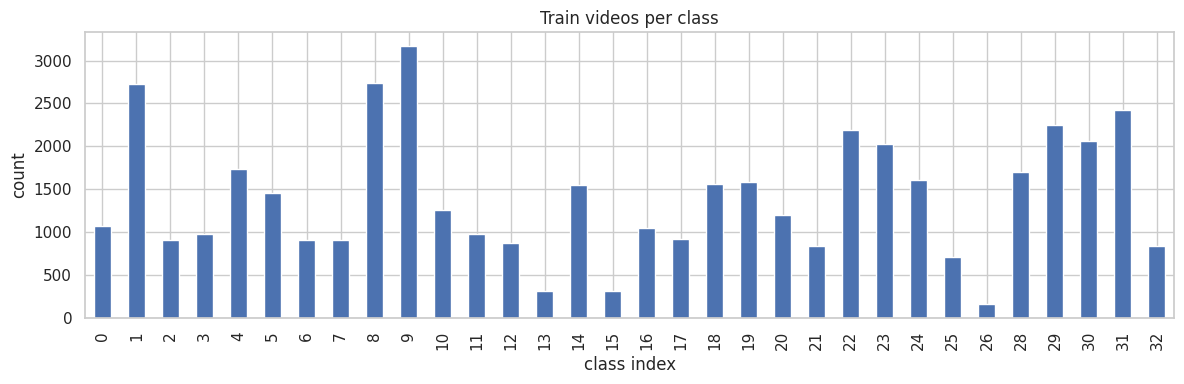

In [8]:
counts = df_train["label"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(12, 4))
counts.plot.bar(ax=ax)
ax.set_title("Train videos per class")
ax.set_xlabel("class index")
ax.set_ylabel("count")
plt.tight_layout()

## Frames per video

Detects videos that are too short (sampling will repeat frames) or unusually long.

In [9]:
FRAME_EXTENSIONS = ("*.jpg", "*.jpeg", "*.png", "*.webp")

def list_frame_paths(video_dir: Path) -> list[Path]:
    paths: list[Path] = []
    for ext in FRAME_EXTENSIONS:
        paths.extend(video_dir.glob(ext))
    return sorted(paths, key=lambda p: p.name)

df_train["n_frames"] = df_train["video_dir"].map(lambda p: len(list_frame_paths(p)))
df_train["n_frames"].describe()

count    44993.000000
mean         3.999956
std          0.009429
min          2.000000
25%          4.000000
50%          4.000000
75%          4.000000
max          4.000000
Name: n_frames, dtype: float64

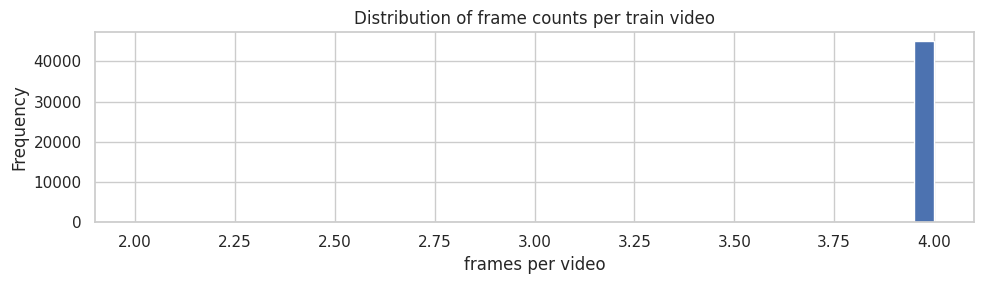

In [10]:
fig, ax = plt.subplots(figsize=(10, 3))
df_train["n_frames"].plot.hist(bins=40, ax=ax)
ax.set_title("Distribution of frame counts per train video")
ax.set_xlabel("frames per video")
plt.tight_layout()

## Preview the first few videos

Each row is a single video; we display `NUM_PREVIEW_FRAMES` evenly-spaced frames from it. Use this to:
- spot corrupted frames (black, garbled),
- sanity-check that class folder names match the visible content,
- get a feel for the temporal dynamics.

In [11]:
NUM_PREVIEW_VIDEOS = 4
NUM_PREVIEW_FRAMES = 6

def evenly_spaced_indices(num_available: int, num_to_pick: int) -> list[int]:
    """Match the dataset's sampling so previews mirror what training sees."""
    if num_available <= 0 or num_to_pick <= 0:
        return []
    if num_available == 1:
        return [0] * num_to_pick
    step = (num_available - 1) / (num_to_pick - 1) if num_to_pick > 1 else 0
    return [int(round(i * step)) for i in range(num_to_pick)]

preview_videos = df_train.head(NUM_PREVIEW_VIDEOS)
preview_videos

,video_dir,label,n_frames
0,/Data/romain.poggi/Modal/project/smth2smth/dat...,0,4
1,/Data/romain.poggi/Modal/project/smth2smth/dat...,0,4
2,/Data/romain.poggi/Modal/project/smth2smth/dat...,0,4
3,/Data/romain.poggi/Modal/project/smth2smth/dat...,0,4


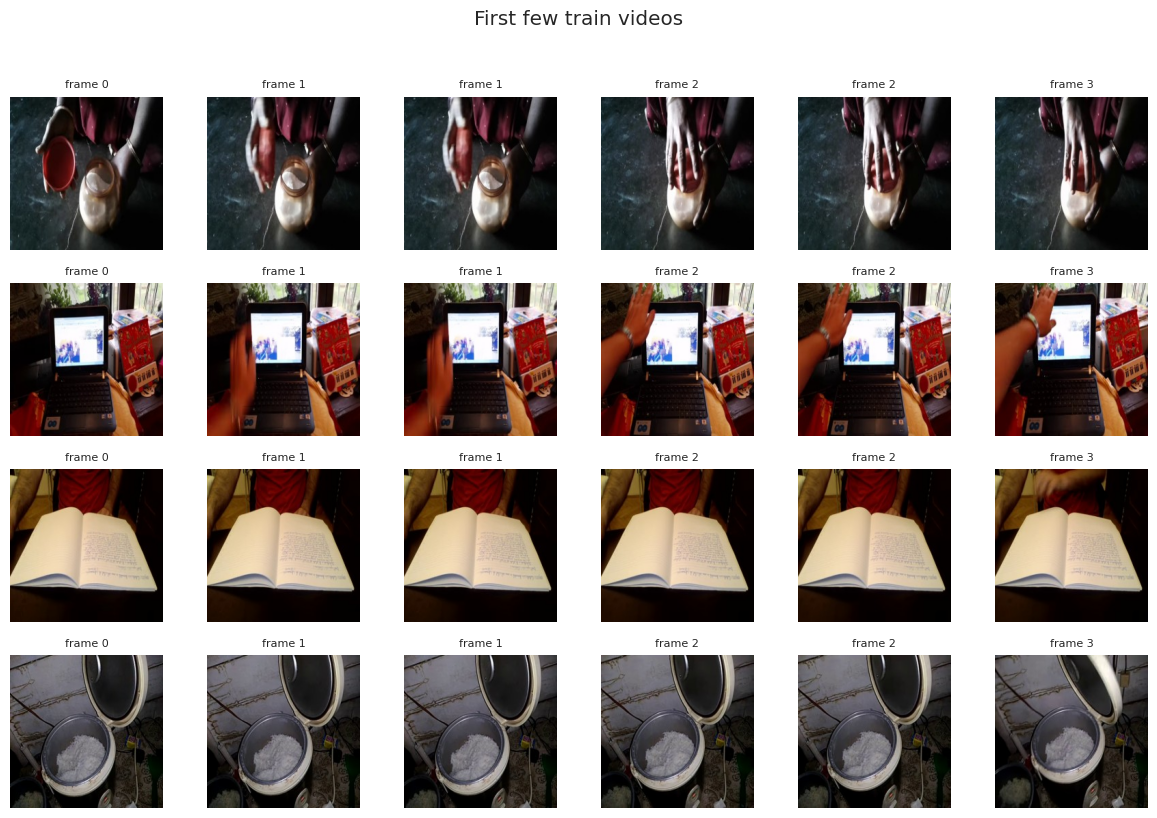

In [12]:
fig, axes = plt.subplots(
    nrows=NUM_PREVIEW_VIDEOS,
    ncols=NUM_PREVIEW_FRAMES,
    figsize=(2 * NUM_PREVIEW_FRAMES, 2 * NUM_PREVIEW_VIDEOS),
    squeeze=False,
)

for row, (_, sample) in enumerate(preview_videos.iterrows()):
    video_dir: Path = sample["video_dir"]
    label: int = int(sample["label"])
    frame_paths = list_frame_paths(video_dir)
    indices = evenly_spaced_indices(len(frame_paths), NUM_PREVIEW_FRAMES)

    for col, idx in enumerate(indices):
        ax = axes[row, col]
        with Image.open(frame_paths[idx]) as img:
            ax.imshow(img.convert("RGB"))
        ax.axis("off")
        if col == 0:
            ax.set_ylabel(
                f"label {label}\n{video_dir.parent.name}\n{video_dir.name}",
                rotation=0,
                labelpad=60,
                ha="right",
                va="center",
                fontsize=8,
            )
        ax.set_title(f"frame {idx}", fontsize=8)

plt.suptitle("First few train videos", y=1.02)
plt.tight_layout()

### One video per class (optional)

Useful when you want a richer overview than just the first few videos: pick one representative video per class and show its middle frame.

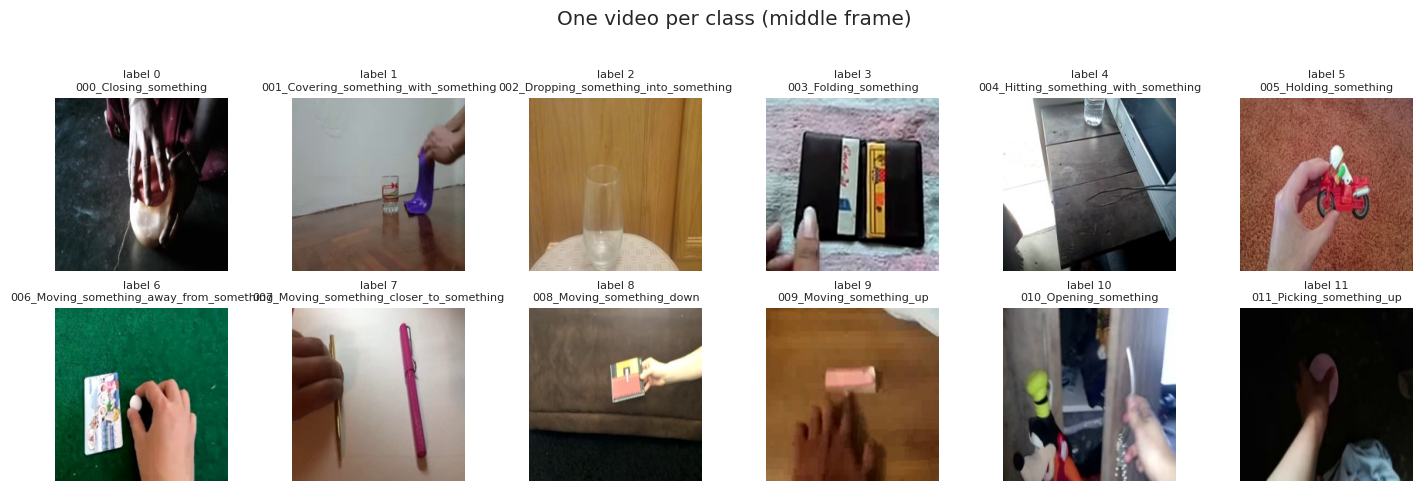

In [13]:
MAX_CLASSES_TO_SHOW = 12
FRAMES_PER_CLASS = 1

first_per_class = (
    df_train.sort_values(["label", "video_dir"])
    .groupby("label", as_index=False)
    .head(1)
    .head(MAX_CLASSES_TO_SHOW)
    .reset_index(drop=True)
)

ncols = min(6, len(first_per_class))
nrows = (len(first_per_class) + ncols - 1) // ncols
fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(2.4 * ncols, 2.4 * nrows),
    squeeze=False,
)

for ax_idx, (_, sample) in enumerate(first_per_class.iterrows()):
    r, c = divmod(ax_idx, ncols)
    ax = axes[r, c]
    frame_paths = list_frame_paths(sample["video_dir"])
    if not frame_paths:
        ax.axis("off")
        continue
    middle = frame_paths[len(frame_paths) // 2]
    with Image.open(middle) as img:
        ax.imshow(img.convert("RGB"))
    ax.axis("off")
    ax.set_title(f"label {int(sample['label'])}\n{sample['video_dir'].parent.name}", fontsize=8)

for ax_idx in range(len(first_per_class), nrows * ncols):
    r, c = divmod(ax_idx, ncols)
    axes[r, c].axis("off")

plt.suptitle("One video per class (middle frame)", y=1.02)
plt.tight_layout()